# Conditional GAN (CGAN)

## Objective

This phase implements a Conditional Generative Adversarial Network (CGAN)
that generates images according to a provided condition or category label.

The model will be trained on a simple synthetic dataset containing two
visual categories:

- Square
- Circle

The conditional label is provided to both the Generator and Discriminator,
allowing the model to learn the relationship between the condition and
the generated visual output.

## Internship Task

**Task 2:** Create a CGAN that uses textual labels or categories to produce
basic visuals. For example, the model should generate appropriate forms when
conditions such as "square" or "circle" are provided.

## Workflow

Condition / Label
→ Generator
→ Generated Image

Image + Condition
→ Discriminator
→ Real / Fake Prediction

The conditional input allows the GAN to learn a relationship between
the provided category and the generated visual output.

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from PIL import Image, ImageDraw

import matplotlib.pyplot as plt
import random
import numpy as np

print("PyTorch version:", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

PyTorch version: 2.14.0+cpu
Device: cpu


## 1. Synthetic Conditional Dataset

To demonstrate the basic concept of a Conditional GAN, a synthetic dataset
containing two visual categories will be created:

- Label 0 → Square
- Label 1 → Circle

Each image will be generated programmatically at a resolution of 64 × 64 pixels.

The images will be normalized to the range [-1, 1] so that they match the
output range of the Generator's Tanh activation.

In [13]:
class ShapeDataset(Dataset):
    def __init__(self, num_samples=1000, image_size=64):
        self.num_samples = num_samples
        self.image_size = image_size

    def __len__(self):
        return self.num_samples

    def __getitem__(self, index):
        image = Image.new(
            "L",
            (self.image_size, self.image_size),
            0
        )

        draw = ImageDraw.Draw(image)

        # Randomly select condition
        label = random.randint(0, 1)

        margin = 12

        if label == 0:
            # Square
            draw.rectangle(
                [
                    margin,
                    margin,
                    self.image_size - margin,
                    self.image_size - margin
                ],
                fill=255
            )

        else:
            # Circle
            draw.ellipse(
                [
                    margin,
                    margin,
                    self.image_size - margin,
                    self.image_size - margin
                ],
                fill=255
            )

        # Convert image to tensor
        image = torch.tensor(
            list(image.getdata()),
            dtype=torch.float32
        ).reshape(
            1,
            self.image_size,
            self.image_size
        ) / 255.0

        # Normalize from [0, 1] to [-1, 1]
        image = image * 2 - 1

        return image, label


shape_dataset = ShapeDataset(
    num_samples=1000,
    image_size=64
)

print("Dataset created successfully!")
print("Number of samples:", len(shape_dataset))
print("Image size: 64 x 64")
print("Number of conditions: 2")
print("Condition 0: Square")
print("Condition 1: Circle")

Dataset created successfully!
Number of samples: 1000
Image size: 64 x 64
Number of conditions: 2
Condition 0: Square
Condition 1: Circle


In [14]:
sample_image, sample_label = shape_dataset[0]

print("Sample image shape:", sample_image.shape)
print("Sample label:", sample_label)
print("Minimum pixel value:", sample_image.min().item())
print("Maximum pixel value:", sample_image.max().item())

Sample image shape: torch.Size([1, 64, 64])
Sample label: 0
Minimum pixel value: -1.0
Maximum pixel value: 1.0


C:\Users\SHIVA SHANKAR\AppData\Local\Temp\ipykernel_22248\2586865907.py:49: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  list(image.getdata()),


C:\Users\SHIVA SHANKAR\AppData\Local\Temp\ipykernel_22248\2586865907.py:49: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  list(image.getdata()),


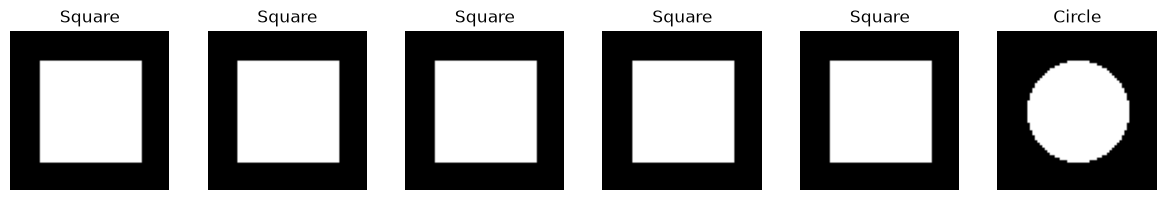

In [15]:
fig, axes = plt.subplots(1, 6, figsize=(12, 2))

for i in range(6):
    image, label = shape_dataset[i]

    # Convert [-1, 1] back to [0, 1] for display
    display_image = (image.squeeze() + 1) / 2

    axes[i].imshow(display_image, cmap="gray")
    axes[i].set_title(
        "Square" if label == 0 else "Circle"
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 2. DataLoader

The DataLoader divides the synthetic dataset into batches so that the
Conditional GAN can process multiple training examples at once.

A batch size of 32 is used for the training experiment.

In [16]:
batch_size = 32

dataloader = DataLoader(
    shape_dataset,
    batch_size=batch_size,
    shuffle=True
)

print("DataLoader created successfully!")
print("Batch size:", batch_size)
print("Number of batches:", len(dataloader))

DataLoader created successfully!
Batch size: 32
Number of batches: 32


In [17]:
images, labels = next(iter(dataloader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Labels:", labels[:10])

Image batch shape: torch.Size([32, 1, 64, 64])
Label batch shape: torch.Size([32])
Labels: tensor([1, 0, 1, 0, 0, 1, 0, 0, 0, 0])


C:\Users\SHIVA SHANKAR\AppData\Local\Temp\ipykernel_22248\2586865907.py:49: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  list(image.getdata()),


## 3. Conditional Generator

The Generator receives two inputs:

1. Random noise
2. A conditional category label

The category label is converted into an embedding and concatenated with
the random noise vector.

The Generator then transforms this combined representation into a
64 × 64 grayscale image.

The output uses the Tanh activation function, producing pixel values
in the range [-1, 1].

In [38]:
class Generator(nn.Module):
    def __init__(
        self,
        noise_dim=100,
        num_classes=2,
        image_size=64
    ):
        super().__init__()

        self.noise_dim = noise_dim

        # Convert the class label into a learned embedding
        self.label_embedding = nn.Embedding(
            num_classes,
            32
        )

        # Combine noise and conditional embedding
        self.fc = nn.Linear(
            noise_dim + 32,
            256 * 4 * 4
        )

        # Upsample from 4x4 → 8x8 → 16x16 → 32x32 → 64x64
        self.model = nn.Sequential(

            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                256,
                128,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                128,
                64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                64,
                32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                32,
                1,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.Tanh()
        )

    def forward(self, noise, labels):

        # Convert labels to embeddings
        label_condition = self.label_embedding(labels)

        # Combine random noise with conditional information
        generator_input = torch.cat(
            (noise, label_condition),
            dim=1
        )

        # Project into feature representation
        x = self.fc(generator_input)

        # Reshape into convolutional feature maps
        x = x.view(
            x.size(0),
            256,
            4,
            4
        )

        # Generate image
        image = self.model(x)

        return image

In [39]:
noise_dim = 100
num_classes = 2
image_size = 64

generator = Generator(
    noise_dim=noise_dim,
    num_classes=num_classes,
    image_size=image_size
).to(device)

print(generator)

Generator(
  (label_embedding): Embedding(2, 32)
  (fc): Linear(in_features=132, out_features=4096, bias=True)
  (model): Sequential(
    (0): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (4): ReLU(inplace=True)
    (5): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (12): Ta

In [40]:
generator.eval()

test_noise = torch.randn(
    2,
    noise_dim,
    device=device
)

test_labels = torch.tensor(
    [0, 1],
    dtype=torch.long,
    device=device
)

with torch.no_grad():
    test_generated_images = generator(
        test_noise,
        test_labels
    )

print("Generated image tensor shape:")
print(test_generated_images.shape)

print("Condition labels:")
print(test_labels)

print("Minimum output value:")
print(test_generated_images.min().item())

print("Maximum output value:")
print(test_generated_images.max().item())

Generated image tensor shape:
torch.Size([2, 1, 64, 64])
Condition labels:
tensor([0, 1])
Minimum output value:
-0.10389483720064163
Maximum output value:
0.07678743451833725


## 4. Conditional Discriminator

The Discriminator receives:

- An image
- Its corresponding condition label

The image and label representation are combined before classification.

The Discriminator outputs a probability indicating whether the image is
real or generated.

In [41]:
class Discriminator(nn.Module):
    def __init__(
        self,
        num_classes=2,
        image_size=64
    ):
        super().__init__()

        self.label_embedding = nn.Embedding(
            num_classes,
            image_size * image_size
        )

        self.model = nn.Sequential(
            nn.Conv2d(
                2,
                64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(
                0.2,
                inplace=True
            ),

            nn.Conv2d(
                64,
                128,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(
                0.2,
                inplace=True
            ),

            nn.Conv2d(
                128,
                256,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(
                0.2,
                inplace=True
            ),

            nn.Conv2d(
                256,
                512,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(
                0.2,
                inplace=True
            ),

            nn.Flatten(),

            nn.Linear(
                512 * 4 * 4,
                1
            ),

            nn.Sigmoid()
        )

    def forward(self, image, labels):

        # Convert labels into a spatial condition map
        label_condition = self.label_embedding(labels)

        label_condition = label_condition.view(
            labels.size(0),
            1,
            image_size,
            image_size
        )

        # Combine image with conditional information
        discriminator_input = torch.cat(
            (image, label_condition),
            dim=1
        )

        validity = self.model(
            discriminator_input
        )

        return validity

In [42]:
discriminator = Discriminator(
    num_classes=num_classes,
    image_size=image_size
).to(device)

print(discriminator)

Discriminator(
  (label_embedding): Embedding(2, 4096)
  (model): Sequential(
    (0): Conv2d(2, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Flatten(start_dim=1, end_dim=-1)
    (12): Linear(in_features=8192, out_features=1, bias=Tru

In [43]:
discriminator.eval()

test_images = torch.randn(
    2,
    1,
    image_size,
    image_size,
    device=device
)

test_labels = torch.tensor(
    [0, 1],
    dtype=torch.long,
    device=device
)

with torch.no_grad():
    test_predictions = discriminator(
        test_images,
        test_labels
    )

print("Discriminator output shape:")
print(test_predictions.shape)

print("Discriminator predictions:")
print(test_predictions)

Discriminator output shape:
torch.Size([2, 1])
Discriminator predictions:
tensor([[0.5082],
        [0.5069]])


## 5. CGAN Training Configuration

The Conditional GAN will be trained using binary cross-entropy loss.

The Generator attempts to produce images that the Discriminator classifies
as real, while the Discriminator learns to distinguish real images from
generated images.

Adam optimization is used for both networks.

In [44]:
learning_rate = 0.0002
num_epochs = 50

criterion = nn.BCELoss()

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

print("Training configuration:")
print("Learning rate:", learning_rate)
print("Number of epochs:", num_epochs)
print("Loss function:", criterion)
print("Optimizer: Adam")

Training configuration:
Learning rate: 0.0002
Number of epochs: 50
Loss function: BCELoss()
Optimizer: Adam


## 6. Conditional GAN Training

During each training iteration:

1. Real images and their labels are passed to the Discriminator.
2. Random noise and labels are passed to the Generator.
3. Generated images are evaluated by the Discriminator.
4. The Discriminator is optimized using real and fake samples.
5. The Generator is optimized to make generated samples appear real.

The same conditional labels are passed to both networks so that the model
learns the relationship between the condition and the generated image.

In [45]:
generator.train()
discriminator.train()

G_losses = []
D_losses = []

for epoch in range(num_epochs):

    epoch_G_loss = 0.0
    epoch_D_loss = 0.0

    for real_images, real_labels in dataloader:

        real_images = real_images.to(device)
        real_labels = real_labels.to(device)

        batch_size = real_images.size(0)

        # ---------------------------------
        # Train Discriminator
        # ---------------------------------

        optimizer_D.zero_grad()

        # Real images
        real_targets = torch.ones(
            batch_size,
            1,
            device=device
        )

        real_output = discriminator(
            real_images,
            real_labels
        )

        real_loss = criterion(
            real_output,
            real_targets
        )

        # Fake images
        noise = torch.randn(
            batch_size,
            noise_dim,
            device=device
        )

        fake_labels = torch.randint(
            0,
            num_classes,
            (batch_size,),
            device=device
        )

        fake_images = generator(
            noise,
            fake_labels
        )

        fake_targets = torch.zeros(
            batch_size,
            1,
            device=device
        )

        fake_output = discriminator(
            fake_images.detach(),
            fake_labels
        )

        fake_loss = criterion(
            fake_output,
            fake_targets
        )

        discriminator_loss = (
            real_loss + fake_loss
        ) / 2

        discriminator_loss.backward()
        optimizer_D.step()

        # ---------------------------------
        # Train Generator
        # ---------------------------------

        optimizer_G.zero_grad()

        noise = torch.randn(
            batch_size,
            noise_dim,
            device=device
        )

        generated_labels = torch.randint(
            0,
            num_classes,
            (batch_size,),
            device=device
        )

        generated_images = generator(
            noise,
            generated_labels
        )

        generator_output = discriminator(
            generated_images,
            generated_labels
        )

        generator_targets = torch.ones(
            batch_size,
            1,
            device=device
        )

        generator_loss = criterion(
            generator_output,
            generator_targets
        )

        generator_loss.backward()
        optimizer_G.step()

        epoch_D_loss += discriminator_loss.item()
        epoch_G_loss += generator_loss.item()

    epoch_D_loss /= len(dataloader)
    epoch_G_loss /= len(dataloader)

    D_losses.append(epoch_D_loss)
    G_losses.append(epoch_G_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"D Loss: {epoch_D_loss:.4f} "
        f"G Loss: {epoch_G_loss:.4f}"
    )

C:\Users\SHIVA SHANKAR\AppData\Local\Temp\ipykernel_22248\2586865907.py:49: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  list(image.getdata()),


Epoch [1/50] D Loss: 0.3235 G Loss: 6.1269
Epoch [2/50] D Loss: 0.4269 G Loss: 3.1064
Epoch [3/50] D Loss: 0.6188 G Loss: 1.4468
Epoch [4/50] D Loss: 0.6738 G Loss: 1.1776
Epoch [5/50] D Loss: 0.6442 G Loss: 1.0562
Epoch [6/50] D Loss: 0.6645 G Loss: 1.0094
Epoch [7/50] D Loss: 0.6870 G Loss: 0.9291
Epoch [8/50] D Loss: 0.6622 G Loss: 0.8640
Epoch [9/50] D Loss: 0.6723 G Loss: 0.9627
Epoch [10/50] D Loss: 0.7299 G Loss: 0.7827
Epoch [11/50] D Loss: 0.6825 G Loss: 0.8008
Epoch [12/50] D Loss: 0.6661 G Loss: 0.7476
Epoch [13/50] D Loss: 0.6979 G Loss: 0.7903
Epoch [14/50] D Loss: 0.7045 G Loss: 0.7817
Epoch [15/50] D Loss: 0.7041 G Loss: 0.7845
Epoch [16/50] D Loss: 0.6852 G Loss: 0.7436
Epoch [17/50] D Loss: 0.6849 G Loss: 0.7471
Epoch [18/50] D Loss: 0.7034 G Loss: 0.7463
Epoch [19/50] D Loss: 0.6942 G Loss: 0.7189
Epoch [20/50] D Loss: 0.6808 G Loss: 0.7449
Epoch [21/50] D Loss: 0.7060 G Loss: 0.7628
Epoch [22/50] D Loss: 0.7002 G Loss: 0.7722
Epoch [23/50] D Loss: 0.6961 G Loss: 0.79

## 7. Training Loss Visualization

The Generator and Discriminator losses are plotted to observe the training
behavior of the Conditional GAN over the training epochs.


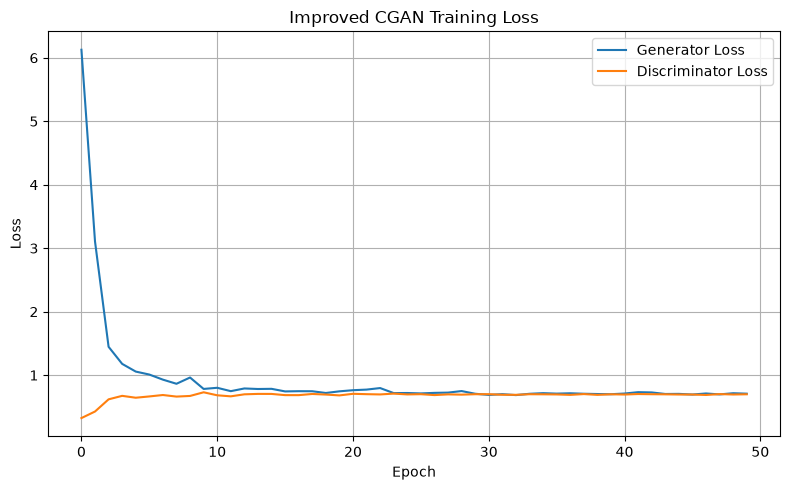

In [46]:
plt.figure(figsize=(8, 5))

plt.plot(
    G_losses,
    label="Generator Loss"
)

plt.plot(
    D_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved CGAN Training Loss")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    generator_losses,
    label="Generator Loss"
)

plt.plot(
    discriminator_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CGAN Training Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 8. Conditional Image Generation

After training, the Generator is used to create images for specific
conditions.

The same random noise can be combined with different labels to demonstrate
the effect of conditional information.

Label 0 represents Square and Label 1 represents Circle.

In [47]:
generator.eval()

test_noise = torch.randn(
    2,
    noise_dim,
    device=device
)

test_labels = torch.tensor(
    [0, 1],
    dtype=torch.long,
    device=device
)

with torch.no_grad():
    generated_images = generator(
        test_noise,
        test_labels
    )

print("Generated conditional images shape:")
print(generated_images.shape)

print("Labels used:")
print(test_labels)

print("Label 0 = Square")
print("Label 1 = Circle")

Generated conditional images shape:
torch.Size([2, 1, 64, 64])
Labels used:
tensor([0, 1])
Label 0 = Square
Label 1 = Circle


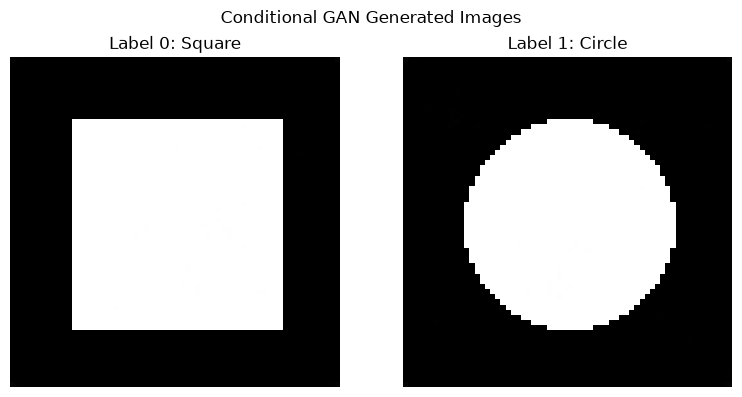

In [48]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(8, 4)
)

labels = ["Square", "Circle"]

for i in range(2):

    image = generated_images[i].detach().cpu()

    # Convert from [-1, 1] to [0, 1]
    image = (image + 1) / 2

    axes[i].imshow(
        image.squeeze(),
        cmap="gray"
    )

    axes[i].set_title(
        f"Label {i}: {labels[i]}"
    )

    axes[i].axis("off")

plt.suptitle(
    "Conditional GAN Generated Images"
)

plt.tight_layout()
plt.show()

## 9. Square vs Circle Conditional Comparison

To clearly demonstrate conditional generation, multiple images will be
generated for each category.

The Generator receives the same type of conditional information while
different random noise vectors are used to produce different samples.

In [49]:
num_examples = 5

square_labels = torch.zeros(
    num_examples,
    dtype=torch.long,
    device=device
)

circle_labels = torch.ones(
    num_examples,
    dtype=torch.long,
    device=device
)

square_noise = torch.randn(
    num_examples,
    noise_dim,
    device=device
)

circle_noise = torch.randn(
    num_examples,
    noise_dim,
    device=device
)

with torch.no_grad():

    square_images = generator(
        square_noise,
        square_labels
    )

    circle_images = generator(
        circle_noise,
        circle_labels
    )

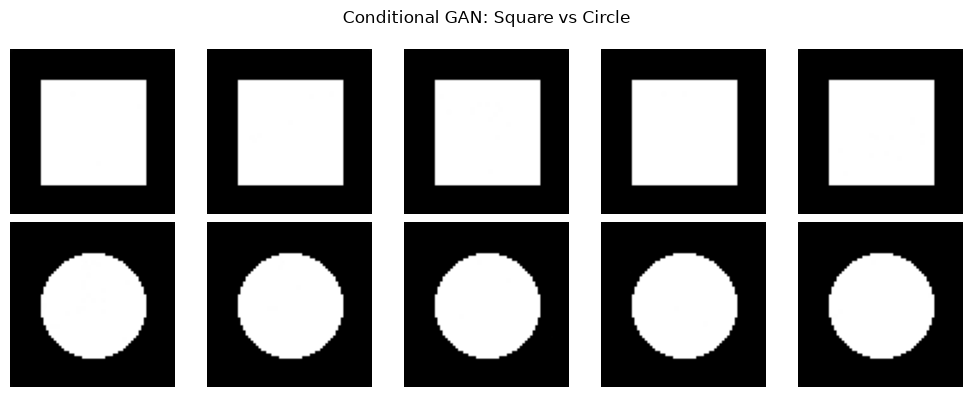

In [50]:
fig, axes = plt.subplots(
    2,
    num_examples,
    figsize=(10, 4)
)

for i in range(num_examples):

    square_image = (
        square_images[i].squeeze() + 1
    ) / 2

    circle_image = (
        circle_images[i].squeeze() + 1
    ) / 2

    axes[0, i].imshow(
        square_image.cpu(),
        cmap="gray"
    )

    axes[0, i].axis("off")

    axes[1, i].imshow(
        circle_image.cpu(),
        cmap="gray"
    )

    axes[1, i].axis("off")

axes[0, 0].set_ylabel(
    "Square",
    fontsize=12
)

axes[1, 0].set_ylabel(
    "Circle",
    fontsize=12
)

plt.suptitle(
    "Conditional GAN: Square vs Circle"
)

plt.tight_layout()
plt.show()

## 10. Final Task 2 Verification

The Conditional GAN implementation is verified using the following
components:

- Synthetic conditional dataset
- Square and circle category labels
- Conditional Generator
- Conditional Discriminator
- Label embeddings
- Conditional GAN training
- Generated images based on category labels
- Comparison of square and circle outputs

The generated results demonstrate the basic principle of conditional
image generation, where the provided category influences the type of
visual output produced by the Generator.

In [33]:
print("=== Task 2 Final Verification ===")

print("\nDataset:")
print("✓ Synthetic shape dataset created")
print("✓ Square condition = 0")
print("✓ Circle condition = 1")

print("\nGenerator:")
print("✓ Conditional label embedding")
print("✓ Noise + condition input")
print("✓ 64 x 64 image generation")

print("\nDiscriminator:")
print("✓ Image + condition input")
print("✓ Real/Fake prediction")

print("\nTraining:")
print("✓ Generator trained")
print("✓ Discriminator trained")
print("✓ Training losses recorded")

print("\nConditional Generation:")
print("✓ Square samples generated")
print("✓ Circle samples generated")
print("✓ Conditional comparison completed")

print("\nTask 2 CGAN implementation completed successfully!")

=== Task 2 Final Verification ===

Dataset:
✓ Synthetic shape dataset created
✓ Square condition = 0
✓ Circle condition = 1

Generator:
✓ Conditional label embedding
✓ Noise + condition input
✓ 64 x 64 image generation

Discriminator:
✓ Image + condition input
✓ Real/Fake prediction

Training:
✓ Generator trained
✓ Discriminator trained
✓ Training losses recorded

Conditional Generation:
✓ Square samples generated
✓ Circle samples generated
✓ Conditional comparison completed

Task 2 CGAN implementation completed successfully!


## Task 2 — Findings and Observations

A Conditional Generative Adversarial Network (CGAN) was successfully
implemented to generate basic visual forms according to category labels.

### Dataset

A synthetic dataset containing two visual categories was created:

- Label 0: Square
- Label 1: Circle

Each image has a resolution of 64 × 64 pixels.

### Conditional Generator

The Generator receives a random noise vector together with a conditional
category label. The category label is converted into an embedding and
combined with the noise representation before image generation.

### Conditional Discriminator

The Discriminator receives both an image and its corresponding category
condition. It predicts whether the image is real or generated while taking
the conditional information into account.

### Training

The Generator and Discriminator were trained using binary cross-entropy
loss and Adam optimization.

Training losses were recorded and visualized to examine the behavior of
the adversarial training process.

### Conditional Generation

After training, the Generator was used to produce images for the two
conditions:

- Square
- Circle

The generated samples were compared to demonstrate the influence of the
conditional input.

### Task 2 Requirement

This implementation addresses the Conditional GAN requirement by introducing
conditional category information into both the Generator and Discriminator
and using the conditions to guide basic visual generation.

The CGAN component will later serve as a foundation for integrating more
advanced text-conditioned generation techniques into the complete
text-to-image pipeline.